In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/Fusion")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print("Dataset:", DATA_DIR)
print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())

Dataset: /content/drive/MyDrive/Fusion
Train: True
Validation: True
Test: True


# Glaucoma Detection from Retinal Fundus Images

**Transfer learning with ConvNeXt-Tiny / EfficientNetV2-S, Albumentations, CLAHE, class-imbalance handling, progressive fine-tuning, and threshold optimization.**

**Authors:** Sirem Kaci

> **Research disclaimer:** This notebook is an academic/research project. It is not a clinically validated diagnostic tool and must not be used for medical diagnosis or treatment decisions.

## Objectives

- Build a robust binary classifier for glaucoma screening from retinal fundus images.
- Use transfer learning with modern pretrained computer-vision architectures.
- Address class imbalance during both sampling and loss computation.
- Track clinically relevant classification metrics such as recall, F1-score, and ROC AUC.
- Select the decision threshold on the validation set and evaluate the final model once on an independent test set.

## Pipeline overview

1. Configure the environment and reproducibility settings.
2. Define training and evaluation image transformations.
3. Create deterministic train/validation splits with separate transforms.
4. Build a pretrained ConvNeXt-Tiny or EfficientNetV2-S classifier.
5. Fine-tune progressively, using weighted loss, AdamW, a learning-rate scheduler, and mixed precision.
6. Select a classification threshold using validation F1-score.
7. Report final test metrics and visual diagnostics.


## 1. Imports and Reproducibility

This section loads the project dependencies and configures deterministic random seeds where practical. The notebook is designed to run in Google Colab, but the core code also works in a standard Jupyter environment after the dataset paths are updated.


In [17]:
# =============================================================================
# 1. IMPORTS & REPRODUCIBILITY
# =============================================================================

import os
import random
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import models
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Reproducibility can reduce performance slightly on some GPU workloads.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [18]:
# =============================================================================
# GLOBAL CONFIGURATION
# =============================================================================

IMG_SIZE = 224
BATCH_SIZE = 32             # Adjust according to available GPU memory.
NUM_EPOCHS = 300
LEARNING_RATE = 5e-5
FINE_TUNE_LR = 1e-5
WEIGHT_DECAY = 1e-5
LABEL_SMOOTHING = 0.1
PATIENCE = 10
UNFREEZE_EPOCH = 30
VALIDATION_SPLIT = 0.20
POSITIVE_CLASS_NAME = "1"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"
print(f"Device: {DEVICE}")

# Set these paths for your environment. Environment variables make the notebook
# easier to reuse outside Google Colab.
DEFAULT_DATA_ROOT = "/content/drive/MyDrive/Fusion"
DATA_ROOT = Path(os.getenv("GLAUCOMA_DATA_ROOT", DEFAULT_DATA_ROOT))
SAVE_DIR = Path(os.getenv("GLAUCOMA_SAVE_DIR", str(DATA_ROOT / "checkpoints")))
SAVE_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = SAVE_DIR / "best_glaucoma_convnext.pth"

print(f"Dataset root: {DATA_ROOT}")
print(f"Checkpoint directory: {SAVE_DIR}")


Device: cuda
Dataset root: /content/drive/MyDrive/Fusion
Checkpoint directory: /content/drive/MyDrive/Fusion/checkpoints


## 2. Image Transformations

Training images receive stochastic augmentation to improve robustness to acquisition variability and reduce overfitting. Validation and test preprocessing is intentionally deterministic so that metrics are reproducible across runs.

The pipeline uses **CLAHE** for local contrast enhancement, geometric and photometric augmentation during training, ImageNet normalization, and tensor conversion.


In [19]:
# =============================================================================
# 2. TRANSFORMATIONS (ALBUMENTATIONS)
# =============================================================================

class AlbumentationsTransform:
    """Adapter that lets torchvision datasets use an Albumentations pipeline."""

    def __init__(self, pipeline):
        self.pipeline = pipeline

    def __call__(self, image):
        image = np.asarray(image)
        return self.pipeline(image=image)["image"]


train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.CLAHE(clip_limit=(1.0, 4.0), tile_grid_size=(8, 8), p=0.65),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.25),
    A.Rotate(limit=40, p=0.6),
    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25,
        p=0.6,
    ),
    A.HueSaturationValue(
        hue_shift_limit=12,
        sat_shift_limit=20,
        val_shift_limit=20,
        p=0.4,
    ),
    A.GaussNoise(p=0.25),
    A.CoarseDropout(p=0.35),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Deterministic validation/test preprocessing.
val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_transform = AlbumentationsTransform(train_aug)
val_transform = AlbumentationsTransform(val_aug)


## 3. Datasets and DataLoaders

The dataset follows the `torchvision.datasets.ImageFolder` convention. A deterministic index split is created once, then the same indices are applied to two dataset objects with different transforms. This prevents stochastic training augmentation from leaking into validation.

A `WeightedRandomSampler` is used **only for training**. Class weights used by the loss function are also computed from the training split rather than from validation or test data.


In [20]:
# =============================================================================
# 3. DATASETS & DATALOADERS
# =============================================================================

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not directory.exists():
        raise FileNotFoundError(
            f"Dataset folder not found: {directory}"
        )

# Load datasets
train_ds = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_ds = ImageFolder(
    VAL_DIR,
    transform=val_transform
)

test_ds = ImageFolder(
    TEST_DIR,
    transform=val_transform
)

# Make sure class mappings are identical
if not (
    train_ds.class_to_idx
    == val_ds.class_to_idx
    == test_ds.class_to_idx
):
    raise ValueError(
        "Train, validation, and test class mappings differ.\n"
        f"Train: {train_ds.class_to_idx}\n"
        f"Validation: {val_ds.class_to_idx}\n"
        f"Test: {test_ds.class_to_idx}"
    )

# Positive class
if POSITIVE_CLASS_NAME not in train_ds.class_to_idx:
    raise ValueError(
        f"Positive class '{POSITIVE_CLASS_NAME}' not found. "
        f"Available classes: {train_ds.classes}"
    )

POSITIVE_CLASS_IDX = train_ds.class_to_idx[POSITIVE_CLASS_NAME]

NEGATIVE_CLASS_IDX = next(
    idx
    for idx in range(len(train_ds.classes))
    if idx != POSITIVE_CLASS_IDX
)

# Training targets
train_targets = np.array(train_ds.targets)

class_counts = np.bincount(
    train_targets,
    minlength=len(train_ds.classes)
)

inverse_frequency = 1.0 / class_counts
sample_weights = inverse_frequency[train_targets]

sampler = WeightedRandomSampler(
    weights=torch.as_tensor(
        sample_weights,
        dtype=torch.double
    ),
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": DEVICE.type == "cuda",
}

train_loader = DataLoader(
    train_ds,
    sampler=sampler,
    drop_last=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_ds,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_ds,
    shuffle=False,
    **loader_kwargs,
)

print(f"Classes: {train_ds.class_to_idx}")
print(
    f"Positive class: '{POSITIVE_CLASS_NAME}' "
    f"(index {POSITIVE_CLASS_IDX})"
)
print(f"Train: {len(train_ds)} images")
print(f"Validation: {len(val_ds)} images")
print(f"Test: {len(test_ds)} images")
print(
    f"Training class counts: "
    f"{class_counts.tolist()}"
)

Classes: {'0': 0, '1': 1}
Positive class: '1' (index 1)
Train: 8354 images
Validation: 770 images
Test: 916 images
Training class counts: [4219, 4135]


## 4. Model Definitions

Two pretrained transfer-learning architectures are defined:

- **ConvNeXt-Tiny** — the default model used in this notebook.
- **EfficientNetV2-S** — an alternative model that can be selected by changing `MODEL_CLASS`.

Each pretrained classifier is replaced by a two-class head. The initial fine-tuning stage freezes the full backbone, then re-enables only the final feature stage and classifier.


In [21]:
# =============================================================================
# 4. MODEL DEFINITIONS
# =============================================================================

class GlaucomaConvNeXt(nn.Module):
    """ConvNeXt-Tiny with a custom binary-classification head."""

    def __init__(self, num_classes=2):
        super().__init__()
        self.base = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        in_features = self.base.classifier[2].in_features
        self.base.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.40),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.base(x)


class GlaucomaEfficientNetV2(nn.Module):
    """EfficientNetV2-S with a custom binary-classification head."""

    def __init__(self, num_classes=2):
        super().__init__()
        self.base = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )
        in_features = self.base.classifier[1].in_features
        self.base.classifier = nn.Sequential(
            nn.Dropout(p=0.40),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.base(x)


MODEL_CLASS = GlaucomaConvNeXt
model = MODEL_CLASS(num_classes=len(train_ds.classes)).to(DEVICE)

print(f"Selected model: {MODEL_CLASS.__name__}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Selected model: GlaucomaConvNeXt
Total parameters: 27,821,666


## 5. Progressive Fine-Tuning

Transfer learning begins with most pretrained features frozen. Only the final feature block and classifier are trainable at first. At `UNFREEZE_EPOCH`, the complete backbone is unfrozen and optimization continues with a lower learning rate.

This staged approach reduces the risk of destroying useful pretrained representations early in training.


In [22]:
# =============================================================================
# 5. INITIAL FREEZING STRATEGY
# =============================================================================

for parameter in model.base.parameters():
    parameter.requires_grad = False

# Both supported torchvision architectures expose .features and .classifier.
for parameter in model.base.features[-1].parameters():
    parameter.requires_grad = True

for parameter in model.base.classifier.parameters():
    parameter.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Initial fine-tuning configuration:")
print("  - Final feature block: trainable")
print("  - Classifier: trainable")
print("  - Earlier feature blocks: frozen")
print(
    f"Trainable parameters: {trainable_params:,} / {total_params:,} "
    f"({100 * trainable_params / total_params:.1f}%)"
)

Initial fine-tuning configuration:
  - Final feature block: trainable
  - Classifier: trainable
  - Earlier feature blocks: frozen
Trainable parameters: 14,292,482 / 27,821,666 (51.4%)


## 6. Loss, Optimizer, Scheduler, and Mixed Precision

Class weights are computed **only from the training split** and passed to `CrossEntropyLoss`. Label smoothing provides additional regularization.

The optimizer is AdamW and the scheduler is `ReduceLROnPlateau`, driven by validation F1-score. Automatic Mixed Precision (AMP) is enabled only when training on CUDA.


In [23]:
# =============================================================================
# 6. LOSS - OPTIMIZER - SCHEDULER - AMP SCALER
# =============================================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(train_ds.classes)),
    y=train_targets,
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)


def make_optimizer_and_scheduler(parameters, learning_rate):
    optimizer = optim.AdamW(
        parameters,
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
    )
    return optimizer, scheduler


optimizer, scheduler = make_optimizer_and_scheduler(
    filter(lambda p: p.requires_grad, model.parameters()),
    LEARNING_RATE,
)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

print("Training components initialized.")
print(f"Class weights: {class_weights.detach().cpu().numpy()}")
print(f"Initial learning rate: {LEARNING_RATE}")
print(f"AMP enabled: {AMP_ENABLED}")


Training components initialized.
Class weights: [0.990045  1.0101572]
Initial learning rate: 5e-05
AMP enabled: True


## 7. Evaluation Function

The evaluation function reports loss, accuracy, precision, recall, F1-score, ROC AUC, the confusion matrix, predicted probabilities, predictions, and labels.

The positive-class index is derived from `ImageFolder.class_to_idx` instead of assuming that glaucoma is class `1`. This is important because `ImageFolder` assigns indices alphabetically.


In [24]:
# =============================================================================
# 7. EVALUATION FUNCTION
# =============================================================================

@torch.no_grad()
def evaluate(loader, model, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total = 0
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in tqdm(loader, desc="Evaluation", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=AMP_ENABLED,
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        positive_probs = torch.softmax(logits, dim=1)[:, POSITIVE_CLASS_IDX]
        preds = torch.where(
            positive_probs >= threshold,
            torch.full_like(labels, POSITIVE_CLASS_IDX),
            torch.full_like(labels, NEGATIVE_CLASS_IDX),
        )

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total += batch_size
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(positive_probs.cpu().numpy())

    labels_np = np.asarray(all_labels)
    preds_np = np.asarray(all_preds)
    probs_np = np.asarray(all_probs)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_np,
        preds_np,
        average="binary",
        pos_label=POSITIVE_CLASS_IDX,
        zero_division=0,
    )

    binary_targets = (labels_np == POSITIVE_CLASS_IDX).astype(int)
    try:
        auc = roc_auc_score(binary_targets, probs_np)
    except ValueError:
        auc = np.nan

    cm = confusion_matrix(
        labels_np,
        preds_np,
        labels=list(range(len(train_ds.classes))),
    )

    return {
        "loss": total_loss / total,
        "acc": 100.0 * np.mean(preds_np == labels_np),
        "precision": 100.0 * precision,
        "recall": 100.0 * recall,
        "f1": 100.0 * f1,
        "auc": 100.0 * auc,
        "cm": cm,
        "probs": probs_np,
        "preds": preds_np,
        "labels": labels_np,
        "threshold": threshold,
    }


## 8. Main Training Loop

The model is trained with validation tracking, checkpointing, early stopping, and progressive full-model unfreezing. When the optimizer is recreated after unfreezing, the learning-rate scheduler is recreated as well so that it remains attached to the active optimizer.

Model selection is based on validation F1-score.


In [25]:
# =============================================================================
# 8. MAIN TRAINING LOOP
# =============================================================================


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_auc": [],
    "val_recall": [],
}

best_val_f1 = -np.inf
best_epoch = 0
patience_counter = 0
has_unfrozen = False

print("\n" + "=" * 80)
print(f"STARTING TRAINING - {MODEL_CLASS.__name__}".center(80))
print("=" * 80 + "\n")

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == UNFREEZE_EPOCH and not has_unfrozen:
        print("\nUnfreezing the full pretrained backbone.\n")

        for parameter in model.base.parameters():
            parameter.requires_grad = True

        optimizer, scheduler = make_optimizer_and_scheduler(
            model.parameters(),
            FINE_TUNE_LR,
        )

        has_unfrozen = True

    # -------------------------------------------------------------------------
    # TRAINING
    # -------------------------------------------------------------------------

    model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch:03d}/{NUM_EPOCHS} [Train]",
        leave=True,
    )

    for images, labels in progress:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=AMP_ENABLED
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        train_loss_sum += loss.item() * batch_size

        train_correct += (
            logits.argmax(dim=1) == labels
        ).sum().item()

        train_total += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = train_loss_sum / train_total

    train_acc = (
        100.0 * train_correct / train_total
    )

    # -------------------------------------------------------------------------
    # VALIDATION
    # -------------------------------------------------------------------------

    # Use threshold 0.5 during model selection.
    # Threshold optimization happens later on validation data.

    val_metrics = evaluate(
        val_loader,
        model,
        criterion,
        DEVICE,
        threshold=0.5
    )

    # -------------------------------------------------------------------------
    # HISTORY
    # -------------------------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["val_acc"].append(
        val_metrics["acc"]
    )

    history["val_f1"].append(
        val_metrics["f1"]
    )

    history["val_auc"].append(
        val_metrics["auc"]
    )

    history["val_recall"].append(
        val_metrics["recall"]
    )

    # -------------------------------------------------------------------------
    # LOGGING
    # -------------------------------------------------------------------------

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
        f"Train loss {train_loss:.4f} | "
        f"Train acc {train_acc:6.2f}% | "
        f"Val loss {val_metrics['loss']:.4f} | "
        f"Val acc {val_metrics['acc']:6.2f}% | "
        f"F1 {val_metrics['f1']:6.2f}% | "
        f"Recall {val_metrics['recall']:6.2f}% | "
        f"AUC {val_metrics['auc']:6.2f}%"
    )

    # -------------------------------------------------------------------------
    # LEARNING RATE SCHEDULER
    # -------------------------------------------------------------------------

    scheduler.step(
        val_metrics["f1"]
    )

    # -------------------------------------------------------------------------
    # BEST MODEL CHECKPOINT + EARLY STOPPING
    # -------------------------------------------------------------------------

    if val_metrics["f1"] > best_val_f1 + 0.01:

        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"New best checkpoint saved "
            f"(validation F1 = {best_val_f1:.2f}%)."
        )

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print(
                f"Early stopping at epoch {epoch}: "
                f"no validation F1 improvement "
                f"for {PATIENCE} consecutive epochs."
            )

            break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("\n" + "=" * 80)

print(
    f"Training complete. "
    f"Best validation F1: {best_val_f1:.2f}% "
    f"at epoch {best_epoch}."
)

print(
    f"Checkpoint: {BEST_MODEL_PATH}"
)

print("=" * 80)


                      STARTING TRAINING - GlaucomaConvNeXt                      



Epoch 001/300 [Train]:   0%|          | 0/261 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001/300 | Train loss 0.6391 | Train acc  64.77% | Val loss 0.4809 | Val acc  82.47% | F1  82.63% | Recall  83.38% | AUC  89.25%
New best checkpoint saved (validation F1 = 82.63%).


Epoch 002/300 [Train]:   0%|          | 0/261 [00:00<?, ?it/s]

...

Epoch 062/300 [Train]:   0%|          | 0/261 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    <function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    if w.is_alive():    
self._shutdown_workers()  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'
    AssertionErrorif w.is_alive():: 
can only test a child process  File "/usr/lib/p

Epoch 062/300 | Train loss 0.3184 | Train acc  92.54% | Val loss 0.3179 | Val acc  93.25% | F1  93.21% | Recall  92.73% | AUC  97.69%
Early stopping at epoch 62: no validation F1 improvement for 10 consecutive epochs.

Training complete. Best validation F1: 93.90% at epoch 52.
Checkpoint: /content/drive/MyDrive/Fusion/checkpoints/best_glaucoma_convnext.pth


## 9. Decision-Threshold Selection on Validation Data

A probability threshold controls the trade-off between false positives and false negatives. To avoid leaking test information into model selection, the threshold is selected **only on the validation set**.

The code below chooses the threshold with the highest validation F1-score from a predefined grid. In a clinical study, the operating point should instead be selected according to a pre-specified clinical objective, such as a minimum required sensitivity.


In [26]:
# =============================================================================
# 9. THRESHOLD SELECTION ON VALIDATION DATA
# =============================================================================

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

threshold_grid = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in threshold_grid:
    metrics = evaluate(val_loader, model, criterion, DEVICE, threshold=float(threshold))
    threshold_results.append((threshold, metrics["f1"], metrics["recall"], metrics["precision"]))
    print(
        f"Threshold {threshold:.2f} | "
        f"F1 {metrics['f1']:.2f}% | "
        f"Recall {metrics['recall']:.2f}% | "
        f"Precision {metrics['precision']:.2f}%"
    )

SELECTED_THRESHOLD, best_threshold_f1, _, _ = max(
    threshold_results,
    key=lambda row: row[1],
)
SELECTED_THRESHOLD = float(SELECTED_THRESHOLD)

print(
    f"\nSelected threshold: {SELECTED_THRESHOLD:.2f} "
    f"(validation F1 = {best_threshold_f1:.2f}%)"
)


Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

Threshold 0.10 | F1 90.20% | Recall 99.22% | Precision 82.68%


Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

    Traceback (most recent call last):
assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
AssertionError: can only test a child process    
self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Threshold 0.15 | F1 92.27% | Recall 99.22% | Precision 86.23%


...

Threshold 0.80 | F1 91.16% | Recall 87.01% | Precision 95.71%


Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

Threshold 0.85 | F1 90.03% | Recall 84.42% | Precision 96.44%


Evaluation:   0%|          | 0/25 [00:00<?, ?it/s]

Threshold 0.90 | F1 87.52% | Recall 79.22% | Precision 97.76%

Selected threshold: 0.25 (validation F1 = 93.91%)


## 10. Final Evaluation on the Independent Test Set

The best validation checkpoint and the validation-selected threshold are now evaluated **once** on the test set. No test result is used to modify the model or threshold.


In [27]:
# =============================================================================
# 10. FINAL TEST-SET EVALUATION
# =============================================================================

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

test_metrics = evaluate(
    test_loader,
    model,
    criterion,
    DEVICE,
    threshold=SELECTED_THRESHOLD,
)

print("\n" + "=" * 60)
print("FINAL EVALUATION ON THE TEST SET".center(60))
print("=" * 60)
print(f"Threshold     : {SELECTED_THRESHOLD:.2f}")
print(f"Test loss     : {test_metrics['loss']:.4f}")
print(f"Test accuracy : {test_metrics['acc']:.2f}%")
print(f"Test precision: {test_metrics['precision']:.2f}%")
print(f"Test recall   : {test_metrics['recall']:.2f}%")
print(f"Test F1       : {test_metrics['f1']:.2f}%")
print(f"Test ROC AUC  : {test_metrics['auc']:.2f}%")


Evaluation:   0%|          | 0/29 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x790e72c0aac0>Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    Traceback (most recent call last):
self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():self._shutdown_workers()

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        assert self._parent_pid == os.getpid(), 'can only test a child process'if w.is_alive():

AssertionError  File "/usr/lib/python3.13/multiprocessing/proce


              FINAL EVALUATION ON THE TEST SET              
Threshold     : 0.25
Test loss     : 0.3481
Test accuracy : 91.16%
Test precision: 86.93%
Test recall   : 95.88%
Test F1       : 91.19%
Test ROC AUC  : 97.15%


## 11. Training Visualizations and Error Analysis

The final section visualizes training dynamics, the test confusion matrix, and the distribution of predicted glaucoma probabilities. These plots are diagnostic aids and should be interpreted together with the quantitative metrics.


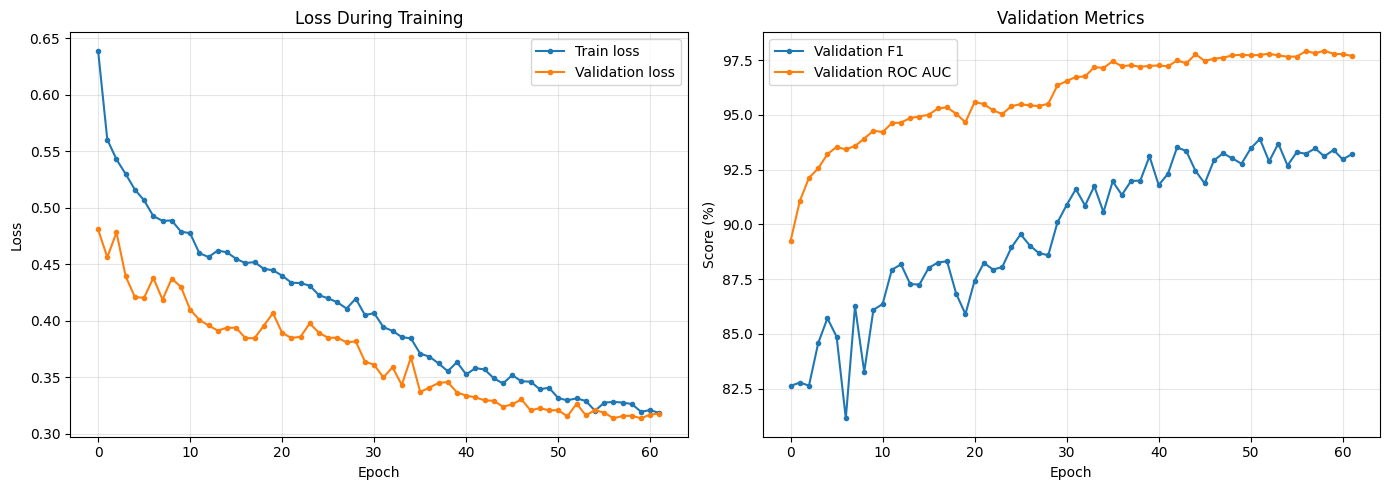

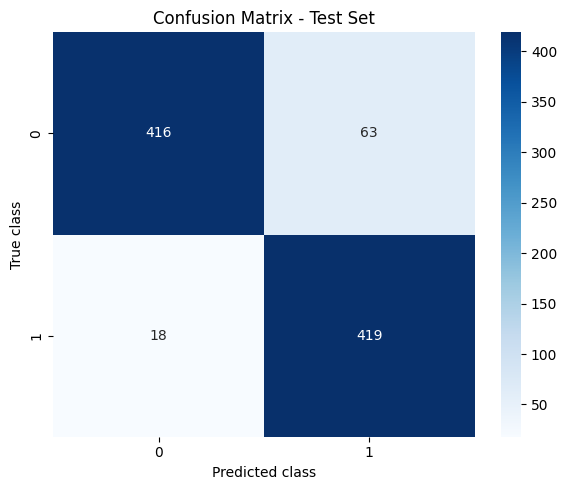

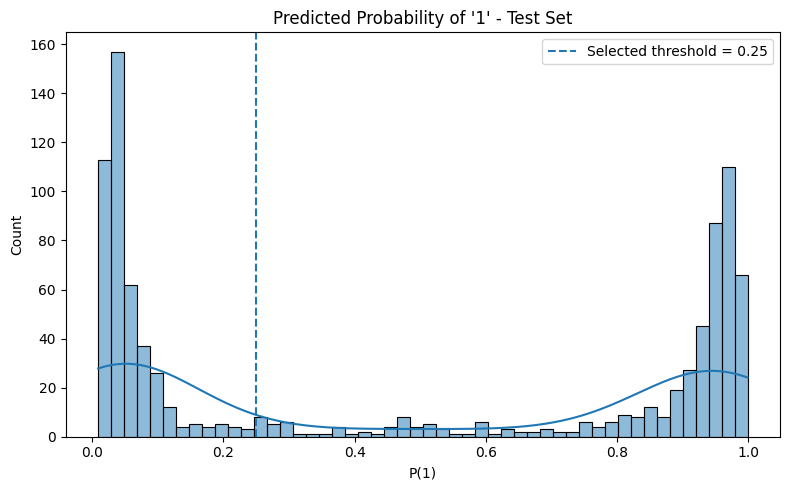

In [28]:
# =============================================================================
# 11. VISUALIZATIONS
# =============================================================================

# Learning curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train loss", marker="o", markersize=3)
plt.plot(history["val_loss"], label="Validation loss", marker="o", markersize=3)
plt.title("Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history["val_f1"], label="Validation F1", marker="o", markersize=3)
plt.plot(history["val_auc"], label="Validation ROC AUC", marker="o", markersize=3)
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    test_metrics["cm"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes,
)
plt.title("Confusion Matrix - Test Set")
plt.ylabel("True class")
plt.xlabel("Predicted class")
plt.tight_layout()
plt.show()

# Positive-class probability distribution
plt.figure(figsize=(8, 5))
sns.histplot(test_metrics["probs"], bins=50, kde=True)
plt.axvline(
    SELECTED_THRESHOLD,
    linestyle="--",
    label=f"Selected threshold = {SELECTED_THRESHOLD:.2f}",
)
plt.title(f"Predicted Probability of '{POSITIVE_CLASS_NAME}' - Test Set")
plt.xlabel(f"P({POSITIVE_CLASS_NAME})")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()